# Modeling Sentiment Analysis UAS Data Mining II Kelompok 12

## Import Library dan Subset Data

In [1]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pickle
import torch
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

In [2]:
df = pd.read_excel("/kaggle/input/dataset-kelompok-12/Data Datmin II_Kelompok 12.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               2000 non-null   float64
 1   created_at               2000 non-null   object 
 2   favorite_count           2000 non-null   int64  
 3   full_text                2000 non-null   object 
 4   id_str                   2000 non-null   float64
 5   image_url                668 non-null    object 
 6   in_reply_to_screen_name  872 non-null    object 
 7   lang                     2000 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              2000 non-null   int64  
 10  reply_count              2000 non-null   int64  
 11  retweet_count            2000 non-null   int64  
 12  tweet_url                2000 non-null   object 
 13  user_id_str              2000 non-null   float64
 14  Sentimen                

In [4]:
df.isna().sum()

Unnamed: 0                    0
created_at                    0
favorite_count                0
full_text                     0
id_str                        0
image_url                  1332
in_reply_to_screen_name    1128
lang                          0
location                   2000
quote_count                   0
reply_count                   0
retweet_count                 0
tweet_url                     0
user_id_str                   0
Sentimen                      0
dtype: int64

In [5]:
df['Sentimen'].value_counts()

Sentimen
2    719
1    694
0    587
Name: count, dtype: int64

## Data Cleaning

Total Data Awal: 2000
Sedang membersihkan data...
-> Dihapus karena kosong/simbol: 2 data
-> Dihapus karena duplikat: 74 data
Total Data Akhir: 1924

CONTOH DATA YANG DIHAPUS

--- [Contoh 1] Dihapus karena isinya hanya Link/Simbol ---
https://t.co/DXCLSBDCHP
https://t.co/6d3wL4JNVP

--- [Contoh 2] Dihapus karena Duplikat (Spam/Bot) ---
@DPR_RI Izin menolak ruu kuhap isinya terlalu m...
Rancangan Undang-Undang Kitab Undang-undang Huk...
DUKUNG PENGESAHAN RUU KUHAP! https://t.co/8H64X...


<Figure size 1000x600 with 0 Axes>

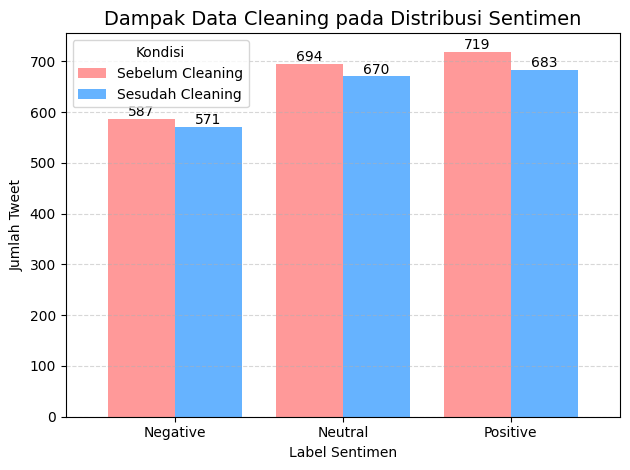

In [6]:
# Mapping Label (0: Negative, 1: Neutral, 2: Positive)
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
df['label_desc'] = df['Sentimen'].map(label_map)

# Hapus baris jika label/text kosong dari awal
df = df.dropna(subset=['full_text', 'label_desc'])

# Simpan Distribusi Awal untuk Visualisasi Nanti
dist_before = df['label_desc'].value_counts().sort_index()
print(f"Total Data Awal: {len(df)}")

# ==========================================
# 2. PROSES CLEANING
# ==========================================
def cleaning_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'\n', ' ', text)                  # Hapus Enter
    text = re.sub(r'http\S+', '', text)              # Hapus Link
    text = re.sub(r'www\.\S+', '', text)             # Hapus Link www
    text = re.sub(r'@\w+', '', text)                 # Hapus Mention
    text = re.sub(r'#\w+', '', text)                 # Hapus Hashtag
    text = re.sub(r'\d+', '', text)                  # Hapus Angka
    text = text.translate(str.maketrans('', '', string.punctuation)) # Hapus Simbol
    text = re.sub(r'\s+', ' ', text).strip()         # Hapus Spasi Ganda
    return text

print("Sedang membersihkan data...")
df['clean_text'] = df['full_text'].apply(cleaning_text)

# ==========================================
# 3. IDENTIFIKASI & HAPUS DATA SAMPAH
# ==========================================

# A. Cek data yang jadi kosong setelah cleaning (Isinya cuma link/simbol)
deleted_empty = df[df['clean_text'] == ""]
print(f"-> Dihapus karena kosong/simbol: {len(deleted_empty)} data")

# Hapus data kosong
df = df[df['clean_text'] != ""]

# B. Cek & Hapus Duplikat
# Kita simpan dulu data yang dianggap duplikat untuk contoh
duplicates = df[df.duplicated(subset=['clean_text'], keep='first')]
print(f"-> Dihapus karena duplikat: {len(duplicates)} data")

# Proses hapus duplikat (Keep 'first' = simpan 1, buang sisanya)
df = df.drop_duplicates(subset=['clean_text'], keep='first')

# Simpan Distribusi Akhir
dist_after = df['label_desc'].value_counts().sort_index()
print(f"Total Data Akhir: {len(df)}")

# ==========================================
# 4. TAMPILKAN CONTOH DATA TERHAPUS
# ==========================================
print("\n" + "="*50)
print("CONTOH DATA YANG DIHAPUS")
print("="*50)

print("\n--- [Contoh 1] Dihapus karena isinya hanya Link/Simbol ---")
if not deleted_empty.empty:
    print(deleted_empty['full_text'].head(3).to_string(index=False))
else:
    print("(Tidak ada data kosong)")

print("\n--- [Contoh 2] Dihapus karena Duplikat (Spam/Bot) ---")
if not duplicates.empty:
    print(duplicates['full_text'].head(3).to_string(index=False))
else:
    print("(Tidak ada duplikat)")

# ==========================================
# 5. VISUALISASI PERBANDINGAN
# ==========================================
comp_df = pd.DataFrame({
    'Sebelum Cleaning': dist_before,
    'Sesudah Cleaning': dist_after
}).fillna(0) # Isi 0 jika ada label yang hilang total

# Plotting
plt.figure(figsize=(10, 6))
# Plot bar berdampingan
ax = comp_df.plot(kind='bar', color=['#ff9999', '#66b3ff'], width=0.8)

plt.title('Dampak Data Cleaning pada Distribusi Sentimen', fontsize=14)
plt.ylabel('Jumlah Tweet')
plt.xlabel('Label Sentimen')
plt.xticks(rotation=0)
plt.legend(title='Kondisi')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# A. KAMUS SLANG SUPER LENGKAP (EXPANDED)
# ==========================================
# Tips: Semakin banyak list ini, semakin bagus akurasi model untuk teks alay.
norm_dict = {
    # 1. Ganti Kata Dasar / Singkatan Umum
    'yg': 'yang', 'dgn': 'dengan', 'dlm': 'dalam', 'sdh': 'sudah', 'dh': 'sudah',
    'udh': 'sudah', 'blm': 'belum', 'lom': 'belum', 'krn': 'karena', 'karna': 'karena',
    'bgt': 'banget', 'bgit': 'banget', 'banged': 'banget', 'dr': 'dari', 'kpn': 'kapan',
    'ma': 'sama', 'sm': 'sama', 'utk': 'untuk', 'tuk': 'untuk', 'tujuan': 'tujuan',
    'tp': 'tapi', 'tpi': 'tapi', 'tetep': 'tetap', 'jd': 'jadi', 'jdi': 'jadi',
    'jga': 'juga', 'jg': 'juga', 'cm': 'cuma', 'cma': 'cuma', 'cuman': 'cuma',
    'org': 'orang', 'orng': 'orang', 'bkn': 'bukan', 'tau': 'tahu', 'tw': 'tahu',
    'mw': 'mau', 'mo': 'mau', 'msh': 'masih', 'bs': 'bisa', 'bisaa': 'bisa',
    'sy': 'saya', 'gw': 'saya', 'gue': 'saya', 'aku': 'saya', 'ak': 'saya',
    'lu': 'kamu', 'lo': 'kamu', 'oe': 'kamu', 'km': 'kamu', 'kmu': 'kamu',
    'kalian': 'kalian', 'klian': 'kalian', 'mrk': 'mereka', 'dy': 'dia',
    'kalo': 'kalau', 'klo': 'kalau', 'klu': 'kalau', 'kl': 'kalau',
    'tdk': 'tidak', 'tak': 'tidak', 'gk': 'tidak', 'ga': 'tidak', 'gak': 'tidak',
    'engga': 'tidak', 'enggak': 'tidak', 'gakk': 'tidak', 'ngga': 'tidak',
    'jgn': 'jangan', 'jan': 'jangan', 'sh': 'sih', 'sih': 'sih', 'si': 'sih',
    'dong': 'dong', 'dung': 'dong', 'donk': 'dong', 'deh': 'deh', 'dah': 'deh',
    'kok': 'kok', 'koq': 'kok', 'nya': 'nya', 'ny': 'nya', 'x': 'nya',
    'bnyak': 'banyak', 'banyak': 'banyak', 'dikit': 'sedikit', 'ikit': 'sedikit',
    'emg': 'memang', 'emang': 'memang', 'mang': 'memang', 'bener': 'benar',
    'bnr': 'benar', 'slah': 'salah', 'salah': 'salah', 'knp': 'kenapa',
    'napa': 'kenapa', 'knapa': 'kenapa', 'gmn': 'bagaimana', 'gmna': 'bagaimana',
    'gini': 'begini', 'gitu': 'begitu', 'gtu': 'begitu', 'skrg': 'sekarang',
    'bsok': 'besok', 'lusa': 'lusa', 'kemarin': 'kemarin', 'kmrin': 'kemarin',
    'barusan': 'barusan', 'brusan': 'barusan', 'trus': 'terus', 'trs': 'terus',
    'lg': 'lagi', 'lagi': 'lagi', 'lgi': 'lagi', 'thn': 'tahun', 'bln': 'bulan',
    'mnggu': 'minggu', 'hari': 'hari', 'jam': 'jam', 'menit': 'menit',
    'dtg': 'datang', 'plg': 'pulang', 'mkn': 'makan', 'minum': 'minum',
    'tdr': 'tidur', 'liat': 'lihat', 'lht': 'lihat', 'baca': 'baca',
    'tulis': 'tulis', 'denger': 'dengar', 'dngr': 'dengar', 'ngomong': 'bicara',
    'blg': 'bilang', 'bilang': 'bilang', 'kasih': 'beri', 'ksh': 'beri',
    'minta': 'minta', 'ambil': 'ambil', 'taruh': 'letak', 'simpan': 'simpan',
    'buang': 'buang', 'cari': 'cari', 'ketemu': 'temu', 'ktmu': 'temu',
    'bantu': 'bantu', 'tolong': 'tolong', 'tlg': 'tolong', 'maaf': 'maaf',
    'sori': 'maaf', 'sorry': 'maaf', 'makasih': 'terima kasih', 'tq': 'terima kasih',
    'thanks': 'terima kasih', 'thx': 'terima kasih', 'ok': 'oke', 'oke': 'oke',
    'sip': 'oke', 'yup': 'ya', 'yap': 'ya', 'iya': 'ya', 'ya': 'ya',
    'tidak': 'tidak', 'bukan': 'bukan', 'blm': 'belum', 'sdh': 'sudah',
    'ok': 'baik', 'oke': 'baik', 'sip': 'baik', 'baek': 'baik', 'baik': 'baik',
    'bagus': 'bagus', 'bgs': 'bagus', 'jelek': 'buruk', 'jlk': 'buruk',
    'buruk': 'buruk', 'keren': 'keren', 'mantap': 'mantap', 'top': 'bagus',
    'gila': 'gila', 'parah': 'parah', 'anjir': 'anjing', 'njir': 'anjing',
    'bgst': 'bangsat', 'wkwk': 'tertawa', 'wkwkwk': 'tertawa', 'haha': 'tertawa',
    'hehe': 'tertawa', 'hihi': 'tertawa', 'huhu': 'sedih', 'hiks': 'sedih',

    # 2. Kata Kunci Spesifik Dataset (RUU KUHAP)
    'ruu': 'rancangan undang undang',
    'kuhap': 'kitab undang undang hukum acara pidana',
    'uu': 'undang undang',
    'dpr': 'dewan perwakilan rakyat',
    'ri': 'republik indonesia',
    'polri': 'kepolisian republik indonesia',
    'tni': 'tentara nasional indonesia',
    'kpk': 'komisi pemberantasan korupsi',
    'ham': 'hak asasi manusia',
    'presiden': 'presiden',
    'jokowi': 'joko widodo',
    'prabowo': 'prabowo subianto',
    'gibran': 'gibran rakabuming raka',
    'anies': 'anies baswedan',
    'ganjar': 'ganjar pranowo',
    'mahfud': 'mahfud md',
    'cak imin': 'muhaimin iskandar',
    'kpu': 'komisi pemilihan umum',
    'bawaslu': 'badan pengawas pemilihan umum',
    'mk': 'mahkamah konstitusi',
    'ma': 'mahkamah agung',
    'ky': 'komisi yudisial',
    'setuju': 'setuju',
    'tolak': 'tolak',
    'dukung': 'dukung',
    'sah': 'sah',
    'resmi': 'resmi',
    'demo': 'demonstrasi',
    'aksi': 'aksi',
    'damai': 'damai',
    'rusuh': 'rusuh',
    'korupsi': 'korupsi',
    'kolusi': 'kolusi',
    'nepotisme': 'nepotisme',
    'adil': 'adil',
    'makmur': 'makmur',
    'sejahtera': 'sejahtera',
    'aman': 'aman',
    'damai': 'damai',
    'indonesia': 'indonesia',
    'nkri': 'negara kesatuan republik indonesia',
    'pancasila': 'pancasila',
    'uud': 'undang undang dasar',
    '1945': 'sembilan belas empat lima'
}

# ==========================================
# B. SETUP STOPWORDS & STEMMER
# ==========================================
# 1. Stopwords (Hapus kata tidak penting)
factory_sw = StopWordRemoverFactory()
base_stopwords = factory_sw.get_stop_words()
# PENTING: Jangan hapus kata negasi!
exceptions = {'tidak', 'bukan', 'belum', 'jangan', 'tapi', 'tetapi', 'melainkan', 'padahal', 'kurang'}
final_stopwords = set([word for word in base_stopwords if word not in exceptions])

# 2. Stemmer (Ubah ke kata dasar: "menolak" -> "tolak")
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

# ==========================================
# C. FUNGSI ULTIMATE PREPROCESSING
# ==========================================
def ultimate_preprocessing(text):
    if not isinstance(text, str): return ""

    # 1. Hapus pengulangan karakter berlebih (contoh: "baaaanget" -> "banget")
    # Mengubah karakter yang muncul 3x atau lebih menjadi 1x
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    words = text.split()
    clean_words = []

    for word in words:
        # 2. Normalisasi Slang
        if word in norm_dict:
            word = norm_dict[word]

        # 3. Stopword Removal
        if word not in final_stopwords:
            # 4. Stemming (Opsional: Matikan baris ini jika proses terlalu lama)
            # Stemming Sastrawi cukup berat komputasinya.
            # word = stemmer.stem(word)
            clean_words.append(word)

    return " ".join(clean_words)

# ==========================================
# D. EKSEKUSI
# ==========================================
# Pastikan 'clean_text' (hasil cleaning tahap awal) sudah ada
# Jika belum, jalankan dulu cleaning tahap 1 (hapus simbol/angka/link)

print("Sedang melakukan Ultimate Preprocessing (Normalisasi + Stopwords)...")
# Note: Jika ingin pakai stemming, uncomment baris 'stemmer.stem' di atas
# Tapi hati-hati, stemming Sastrawi lambat untuk ribuan data.
df['clean_text_final'] = df['clean_text'].apply(ultimate_preprocessing)

# Hapus data kosong hasil akhir
df = df[df['clean_text_final'] != ""]

print("\n" + "="*50)
print("HASIL AKHIR KUALITAS DATA")
print("="*50)
print(df[['clean_text', 'clean_text_final']].head(10))

# Simpan data bersih final ini untuk modeling
df.to_csv('data_kuhap_final_clean.csv', index=False)
print("\nData bersih tersimpan sebagai 'data_kuhap_final_clean.csv'. Siap untuk Modeling!")

Sedang melakukan Ultimate Preprocessing (Normalisasi + Stopwords)...

HASIL AKHIR KUALITAS DATA
                                           clean_text  \
0   banyak yg bilang praktekâ² yg ada di ruu kuhap...   
1      izin menolak ruu kuhap isinya terlalu mengatur   
2   zionis selalu geser gawang wkwkwkwk sok bahas ...   
4   ruu kuhap ini bikin makin percaya sama hukum g...   
5   pasalpasal itu bakal membuka perlakuan sewenan...   
6    mau teriakin wowo ah ntar jangan sahin ruu kuhap   
7   ruu kuhap yang menimbulkan kontroversi di kala...   
8   demo tolak ruu kuhap ini digagas oleh badan ek...   
9   ruu kuhap yang baru disahkan dpr jadi uu menga...   
10  serius ini pada mau diam saja ruu perampasan a...   

                                     clean_text_final  
0   banyak bilang praktekâ² rancangan undang undan...  
1   izin menolak rancangan undang undang kitab und...  
2   zionis selalu geser gawang wkwkwkwk sok bahas ...  
4   rancangan undang undang kitab undang undang hu..

## Data Preprcessing

In [8]:
import pandas as pd
import numpy as np
import pickle
import torch
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ==========================================
# 1. SETUP & LOAD DATA
# ==========================================
print("Loading data...")
# Pastikan menggunakan file hasil cleaning terakhir
df = pd.read_csv('/kaggle/input/dataset-kelompok-12/data_kuhap_final_clean.csv')

# Pastikan tidak ada nilai null pada kolom teks
df['clean_text_final'] = df['clean_text_final'].fillna("")
X_text = df['clean_text_final'].values
y = df['Sentimen'].values # Label

# Dictionary untuk menyimpan semua hasil fitur
features = {}

# ==========================================
# 2. FEATURE EXTRACTION METHODS
# ==========================================

# --- METODE 1: Bag of Words (BoW) ---
print("\n[1/5] Extracting Bag of Words (BoW)...")
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(X_text).toarray()
features['BoW'] = X_bow
print(f"Shape: {X_bow.shape}")

# --- METODE 2: TF-IDF ---
print("\n[2/5] Extracting TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(X_text).toarray()
features['TF-IDF'] = X_tfidf
print(f"Shape: {X_tfidf.shape}")

# --- METODE 3: Word2Vec (Average Word Embedding) ---
print("\n[3/5] Extracting Word2Vec (Average)...")
# Tokenisasi sederhana untuk Gensim
tokenized_text = [text.split() for text in X_text]

# Latih model Word2Vec sendiri pada dataset (bisa juga load pretrained)
# Vector size 100, window 5, min_count 1
w2v_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=1, workers=4)

def document_vector(doc):
    # Rata-rata vektor kata dalam satu dokumen
    doc = [word for word in doc if word in w2v_model.wv.key_to_index]
    if len(doc) == 0:
        return np.zeros(100)
    return np.mean(w2v_model.wv[doc], axis=0)

X_w2v = np.array([document_vector(text) for text in tokenized_text])
features['Word2Vec'] = X_w2v
print(f"Shape: {X_w2v.shape}")

# --- HELPER FUNCTION UNTUK BERT FAMILY ---
def get_bert_embeddings(text_list, model_name):
    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    # Pindahkan ke GPU jika tersedia agar cepat
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    embeddings = []

    # Proses batch agar RAM tidak meledak
    batch_size = 32
    for i in tqdm(range(0, len(text_list), batch_size), desc=f"Processing {model_name}"):
        batch_texts = text_list[i:i+batch_size]

        # Tokenisasi
        inputs = tokenizer(list(batch_texts), padding=True, truncation=True, max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # Ambil Last Hidden State (Output Layer Terakhir)
        # Shape: (batch_size, sequence_length, hidden_size)
        last_hidden_state = outputs.last_hidden_state

        # Mean Pooling: Mengambil rata-rata dari semua token untuk representasi kalimat
        # Ini lebih akurat daripada hanya mengambil token [CLS] untuk klasifikasi sentimen
        mean_pooled = last_hidden_state.mean(dim=1)

        embeddings.append(mean_pooled.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# --- METODE 4: IndoBERT (Semantic) ---
print("\n[4/5] Extracting IndoBERT Embeddings...")
# Menggunakan model IndoBERT Base dari IndoBenchmark
try:
    X_indobert = get_bert_embeddings(X_text, "indobenchmark/indobert-base-p1")
    features['IndoBERT'] = X_indobert
    print(f"Shape: {X_indobert.shape}")
except Exception as e:
    print(f"Gagal memproses IndoBERT: {e}")

# --- METODE 5: IndoTweet (Social Media Semantic) ---
print("\n[5/5] Extracting IndoTweet Embeddings...")
# Menggunakan model IndoBERTweet yang dilatih khusus pada data Twitter Indonesia
try:
    X_indotweet = get_bert_embeddings(X_text, "indolem/indobertweet-base-uncased")
    features['IndoTweet'] = X_indotweet
    print(f"Shape: {X_indotweet.shape}")
except Exception as e:
    print(f"Gagal memproses IndoTweet: {e}")

# ==========================================
# 3. SIMPAN DATA UNTUK MODELING
# ==========================================
print("\nMenyimpan semua fitur ke 'features_data.pkl'...")
# Kita simpan label (y) juga agar sepaket
data_pack = {
    'y': y,
    'features': features
}

with open('features_data.pkl', 'wb') as f:
    pickle.dump(data_pack, f)

print("Selesai! File 'features_data.pkl' siap digunakan untuk 125 eksperimen modeling.")

Loading data...

[1/5] Extracting Bag of Words (BoW)...
Shape: (1924, 5000)

[2/5] Extracting TF-IDF...
Shape: (1924, 5000)

[3/5] Extracting Word2Vec (Average)...
Shape: (1924, 100)

[4/5] Extracting IndoBERT Embeddings...
Loading indobenchmark/indobert-base-p1...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Processing indobenchmark/indobert-base-p1: 100%|██████████| 61/61 [00:03<00:00, 17.21it/s]
/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Shape: (1924, 768)

[5/5] Extracting IndoTweet Embeddings...
Loading indolem/indobertweet-base-uncased...


Processing indolem/indobertweet-base-uncased: 100%|██████████| 61/61 [00:03<00:00, 18.84it/s]


Shape: (1924, 768)

Menyimpan semua fitur ke 'features_data.pkl'...
Selesai! File 'features_data.pkl' siap digunakan untuk 125 eksperimen modeling.


## Modeling (Screening)

Loading Features Data...

🚀 MULAI SCREENING: 5 Features x 25 Models = 125 Iterations


Total Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Testing BoW:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 607
[LightGBM] [Info] Number of data points in the train set: 1539, number of used features: 205
[LightGBM] [Info] Start training from score -1.214205
[LightGBM] [Info] Start training from score -1.054754
[LightGBM] [Info] Start training from score -1.036269


...

✅ IndoBERT Done. Best: XGBoost (F1: 0.7700)


Testing IndoTweet:   0%|          | 0/25 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008803 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 1539, number of used features: 768
[LightGBM] [Info] Start training from score -1.214205
[LightGBM] [Info] Start training from score -1.054754
[LightGBM] [Info] Start training from score -1.036269


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ IndoTweet Done. Best: SVM (Poly) (F1: 0.7735)


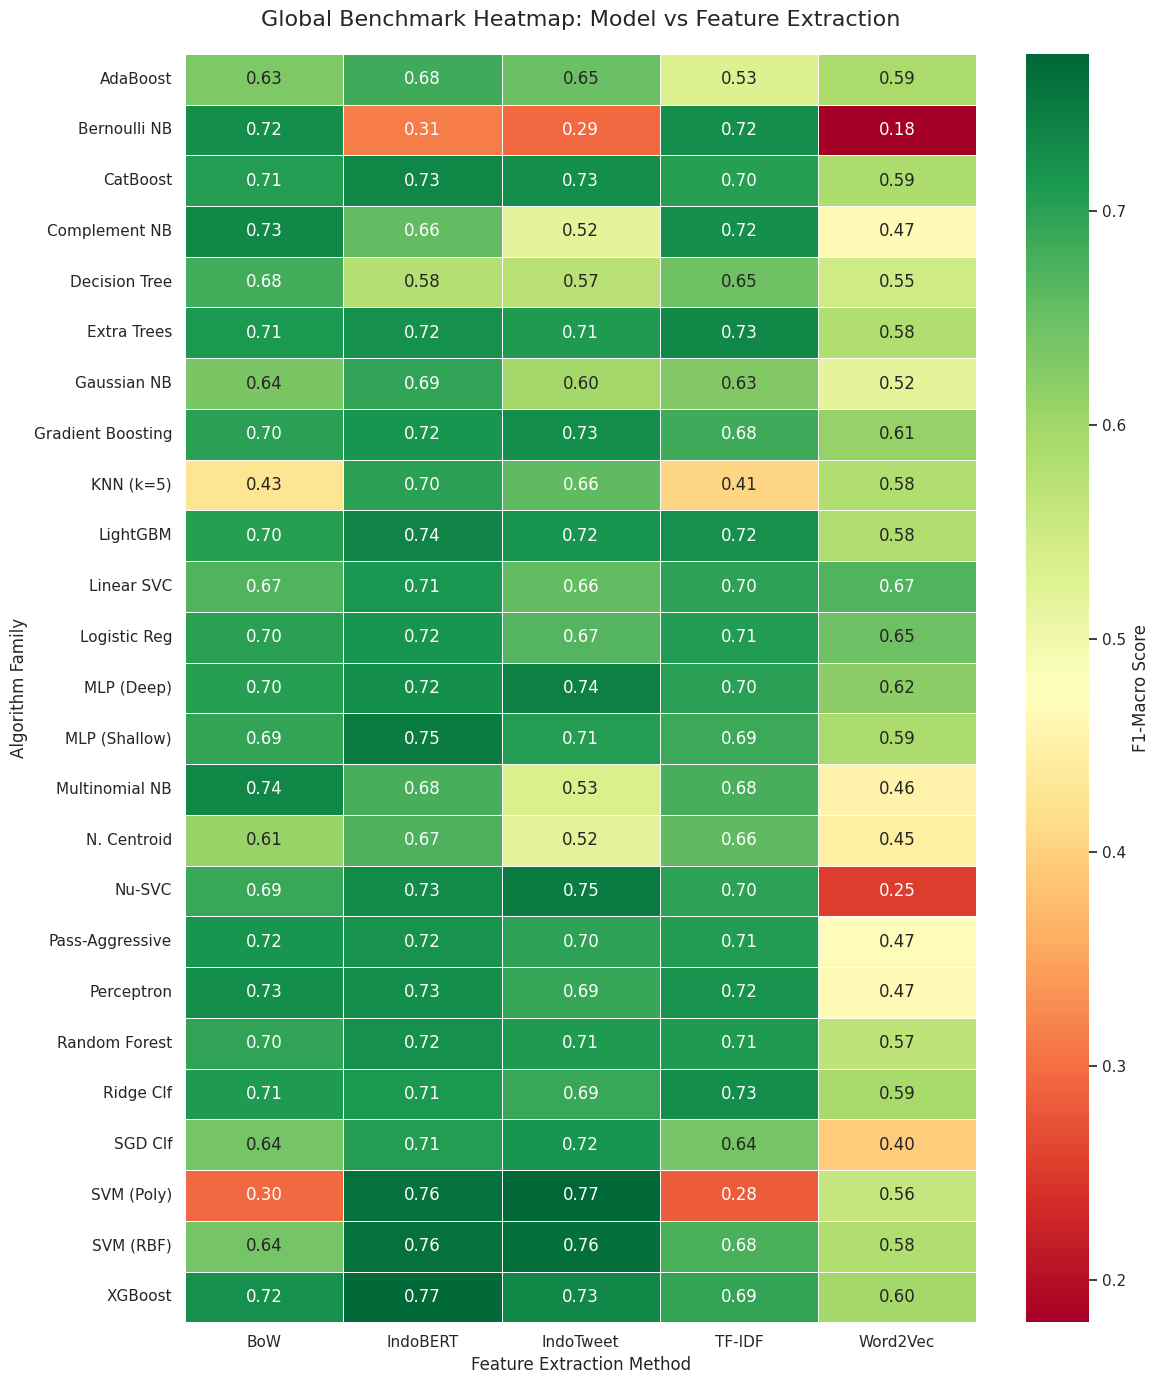

/tmp/ipykernel_732/1283090078.py:192: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_732/1283090078.py:193: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.savefig('2_leaderboard_top10.png')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


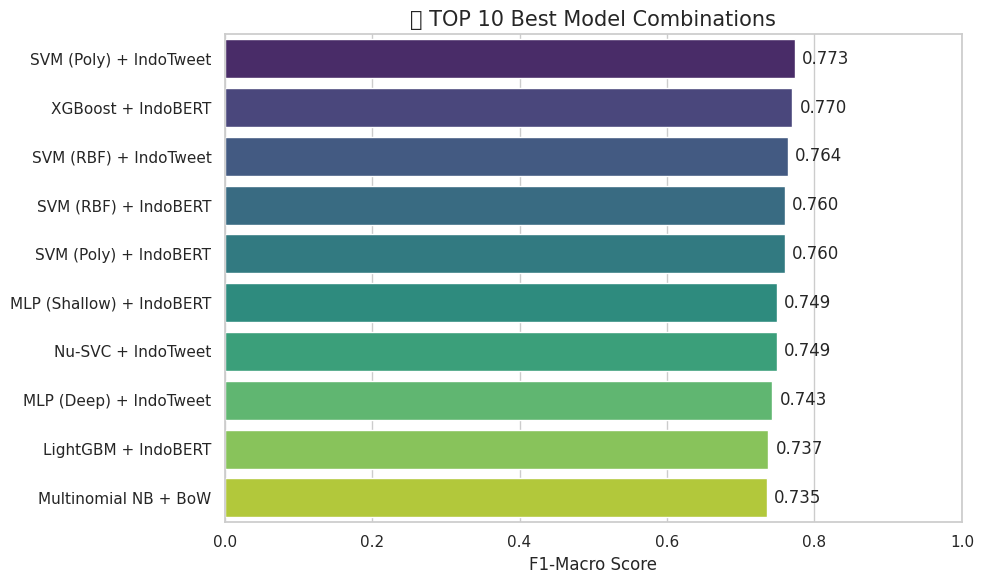

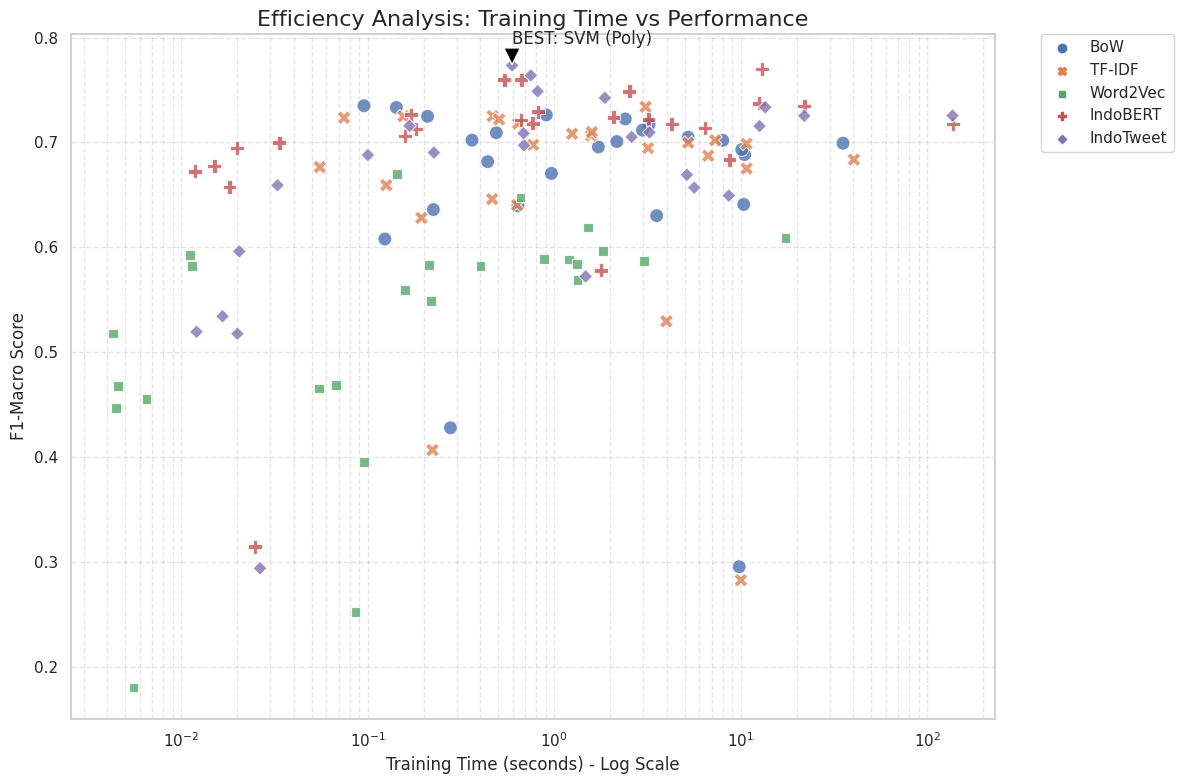


🎉 EKSPERIMEN SELESAI!
1. Cek '1_benchmark_heatmap.png' untuk melihat peta kekuatan model.
2. Cek '2_leaderboard_top10.png' untuk melihat juara bertahan.
3. Cek '3_efficiency_plot.png' untuk analisis kecepatan.
4. Data lengkap tersimpan di 'benchmark_results_final.csv'


In [9]:
import pandas as pd
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# --- IMPORT MODELS ---
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier, Perceptron
from sklearn.svm import LinearSVC, SVC, NuSVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.neural_network import MLPClassifier

# Boosting Check
try: from xgboost import XGBClassifier
except: XGBClassifier = None
try: from lightgbm import LGBMClassifier
except: LGBMClassifier = None
try: from catboost import CatBoostClassifier
except: CatBoostClassifier = None

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
def get_models():
    models = {}
    # A. Linear
    models['Logistic Reg'] = LogisticRegression(max_iter=1000, class_weight='balanced')
    models['Ridge Clf'] = RidgeClassifier(class_weight='balanced')
    models['SGD Clf'] = SGDClassifier(class_weight='balanced', early_stopping=True)
    models['Pass-Aggressive'] = PassiveAggressiveClassifier(class_weight='balanced')
    models['Perceptron'] = Perceptron(class_weight='balanced')
    # B. SVM
    models['Linear SVC'] = LinearSVC(dual=False, class_weight='balanced')
    models['SVM (RBF)'] = SVC(kernel='rbf', class_weight='balanced')
    models['SVM (Poly)'] = SVC(kernel='poly', degree=2, class_weight='balanced')
    models['Nu-SVC'] = NuSVC(nu=0.1)
    # C. Naive Bayes
    models['Multinomial NB'] = MultinomialNB()
    models['Bernoulli NB'] = BernoulliNB()
    models['Complement NB'] = ComplementNB()
    models['Gaussian NB'] = GaussianNB()
    # D. Tree & Ensemble
    models['Decision Tree'] = DecisionTreeClassifier(class_weight='balanced')
    models['Random Forest'] = RandomForestClassifier(n_estimators=100, class_weight='balanced')
    models['Extra Trees'] = ExtraTreesClassifier(n_estimators=100, class_weight='balanced')
    models['AdaBoost'] = AdaBoostClassifier(n_estimators=50)
    models['Gradient Boosting'] = GradientBoostingClassifier(n_estimators=100)
    if XGBClassifier: models['XGBoost'] = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)
    if LGBMClassifier: models['LightGBM'] = LGBMClassifier(n_estimators=100)
    if CatBoostClassifier: models['CatBoost'] = CatBoostClassifier(verbose=0, n_estimators=100)
    # E. Distance & Neural
    models['KNN (k=5)'] = KNeighborsClassifier(n_neighbors=5)
    models['N. Centroid'] = NearestCentroid()
    models['MLP (Shallow)'] = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
    models['MLP (Deep)'] = MLPClassifier(hidden_layer_sizes=(100, 50, 25), max_iter=500)
    return models

# ==========================================
# 2. LOAD DATA
# ==========================================
print("Loading Features Data...")
with open('features_data.pkl', 'rb') as f:
    data_pack = pickle.load(f)

y = data_pack['y']
features_dict = data_pack['features']

# ==========================================
# 3. TRAINING ENGINE
# ==========================================
results = []
models_list = get_models()

print(f"\n🚀 MULAI SCREENING: {len(features_dict)} Features x {len(models_list)} Models = {len(features_dict)*len(models_list)} Iterations")
print("="*80)

# Progress Bar Luar (Fitur)
pbar_outer = tqdm(features_dict.items(), desc="Total Progress", position=0)

for feature_name, X in pbar_outer:

    # Split 80:20
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Progress Bar Dalam (Model)
    pbar_inner = tqdm(models_list.items(), desc=f"Testing {feature_name}", leave=False, position=1)

    best_f1_in_batch = 0
    best_model_in_batch = ""

    for model_name, model in pbar_inner:
        start_time = time.time()
        error_msg = None
        acc, f1 = 0, 0

        try:
            X_train, X_test = X_train_raw.copy(), X_test_raw.copy()

            # --- SMART PREPROCESSING ---
            # 1. Handle Negative Values for Naive Bayes
            is_nb = "NB" in model_name and "Gaussian" not in model_name
            if is_nb and (X_train.min() < 0):
                scaler = MinMaxScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

            # 2. Handle Sparse for GaussianNB
            if "Gaussian" in model_name and hasattr(X_train, "toarray"):
                X_train = X_train.toarray()
                X_test = X_test.toarray()

            # 3. Standard Scaling for Distance/Linear Models
            if any(x in model_name for x in ['SVM', 'KNN', 'MLP', 'Logistic', 'SGD', 'SVC']):
                scaler = StandardScaler(with_mean=False)
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

            # --- FIT & PREDICT ---
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro')

            if f1 > best_f1_in_batch:
                best_f1_in_batch = f1
                best_model_in_batch = model_name

        except Exception as e:
            error_msg = str(e)

        duration = time.time() - start_time

        results.append({
            'Feature': feature_name,
            'Model': model_name,
            'Accuracy': acc,
            'F1-Macro': f1,
            'Time (s)': duration,
            'Error': error_msg
        })

    # Print Summary kecil setelah satu fitur selesai
    tqdm.write(f"✅ {feature_name} Done. Best: {best_model_in_batch} (F1: {best_f1_in_batch:.4f})")

# ==========================================
# 4. VISUALISASI HASIL (DASHBOARD)
# ==========================================
df_res = pd.DataFrame(results)
df_res['F1-Macro'] = df_res['F1-Macro'].fillna(0)
df_res.to_csv('benchmark_results_final.csv', index=False)

# Setup Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

# --- VISUAL 1: HEATMAP MATRIX (Performansi Global) ---
pivot_table = df_res.pivot_table(index='Model', columns='Feature', values='F1-Macro')
plt.figure(figsize=(12, 14))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=.5, cbar_kws={'label': 'F1-Macro Score'})
plt.title('Global Benchmark Heatmap: Model vs Feature Extraction', fontsize=16, pad=20)
plt.ylabel('Algorithm Family', fontsize=12)
plt.xlabel('Feature Extraction Method', fontsize=12)
plt.tight_layout()
plt.savefig('1_benchmark_heatmap.png')
plt.show()

# --- VISUAL 2: TOP 10 LEADERBOARD ---
top_10 = df_res.sort_values(by='F1-Macro', ascending=False).head(10)
top_10['Combo'] = top_10['Model'] + " + " + top_10['Feature']

plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=top_10, y='Combo', x='F1-Macro', palette='viridis')
plt.title('🏆 TOP 10 Best Model Combinations', fontsize=15)
plt.xlabel('F1-Macro Score')
plt.ylabel('')
plt.xlim(0, 1.0)
# Label angka di bar
for p in barplot.patches:
    width = p.get_width()
    plt.text(width + 0.01, p.get_y() + p.get_height()/2, f'{width:.3f}', va='center')
plt.tight_layout()
plt.savefig('2_leaderboard_top10.png')
plt.show()

# --- VISUAL 3: EFFICIENCY PLOT (Time vs Accuracy) ---
# Filter model yang error (F1=0) agar grafik tidak rusak
df_clean = df_res[df_res['F1-Macro'] > 0]

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df_clean,
    x='Time (s)',
    y='F1-Macro',
    hue='Feature',
    style='Feature',
    s=100,
    alpha=0.8,
    palette='deep'
)
plt.title('Efficiency Analysis: Training Time vs Performance', fontsize=16)
plt.xlabel('Training Time (seconds) - Log Scale', fontsize=12)
plt.ylabel('F1-Macro Score', fontsize=12)
plt.xscale('log') # Log scale karena waktu training bisa sangat beda jauh (0.1s vs 100s)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Anotasi Model Terbaik di Grafik
best_row = df_clean.loc[df_clean['F1-Macro'].idxmax()]
plt.annotate(f"BEST: {best_row['Model']}",
             (best_row['Time (s)'], best_row['F1-Macro']),
             xytext=(best_row['Time (s)'], best_row['F1-Macro']+0.02),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.savefig('3_efficiency_plot.png')
plt.show()

print("\n🎉 EKSPERIMEN SELESAI!")
print("1. Cek '1_benchmark_heatmap.png' untuk melihat peta kekuatan model.")
print("2. Cek '2_leaderboard_top10.png' untuk melihat juara bertahan.")
print("3. Cek '3_efficiency_plot.png' untuk analisis kecepatan.")
print("4. Data lengkap tersimpan di 'benchmark_results_final.csv'")

## Modelling (Fine Tuning)

In [10]:
# !pip uninstall -y transformers accelerate peft protobuf numpy

# !pip install protobuf==3.20.3 "numpy<2.0" transformers==4.38.2 accelerate==0.27.2 peft==0.8.2

In [12]:
# ==========================================
# CHUNK 1: FINE-TUNING INDOBERT & INDOTWEET (OPTIMIZED)
# ==========================================
import pandas as pd
import numpy as np
import torch
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# 1. Setup Data
print("📂 Menyiapkan Data untuk Fine-Tuning...")
df = pd.read_csv('/kaggle/input/dataset-kelompok-12/data_kuhap_final_clean.csv')
df['clean_text_final'] = df['clean_text_final'].fillna("")

# Split Data (80:20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text_final'].tolist(),
    df['Sentimen'].tolist(),
    test_size=0.2,
    stratify=df['Sentimen'],
    random_state=42
)

# Convert ke HuggingFace Dataset
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
val_df = pd.DataFrame({'text': val_texts, 'label': val_labels})
hf_train = Dataset.from_pandas(train_df)
hf_val = Dataset.from_pandas(val_df)

# Daftar Model
transformer_models = {
    "IndoBERT": "indobenchmark/indobert-base-p1",
    "IndoTweet": "indolem/indobertweet-base-uncased"
}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

# LOOP TRAINING
for name, model_id in transformer_models.items():
    print(f"\n" + "="*60)
    print(f"🚀 MEMULAI FINE-TUNING: {name} (Scheduler: Cosine + Warmup)")
    print("="*60)

    # A. Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    def tokenize_function(examples):
        return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

    tokenized_train = hf_train.map(tokenize_function, batched=True)
    tokenized_val = hf_val.map(tokenize_function, batched=True)

    # B. Model Load
    model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=3)

    # C. Training Arguments (FIXED VERSION)
    output_dir = f"./results_{name}_optimized"
    training_args = TrainingArguments(
        output_dir=output_dir,
        
        # --- PERBAIKAN DI SINI ---
        evaluation_strategy="epoch", # Gunakan 'evaluation_strategy', bukan 'eval_strategy'
        save_strategy="epoch",
        
        # Hyperparameters
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,

        # SCHEDULER & OPTIMIZATION
        lr_scheduler_type="cosine",    
        warmup_ratio=0.1,              
        fp16=True if torch.cuda.is_available() else False, # Auto-detect GPU                   
        dataloader_num_workers=2,      

        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=1,
        report_to="none" # Matikan reporting ke W&B
    )

    # D. Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
    )

    # E. Train
    trainer.train()

    # Save Final Model
    save_path = f"./final_model_{name}_tuned"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"✅ Model {name} tersimpan di '{save_path}'")

📂 Menyiapkan Data untuk Fine-Tuning...

🚀 MEMULAI FINE-TUNING: IndoBERT (Scheduler: Cosine + Warmup)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/1539 [00:00<?, ? examples/s]

Map:   0%|          | 0/385 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallel

...

Map:   0%|          | 0/385 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling paral

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.600029,0.745455,0.746235
2,No log,0.569892,0.766234,0.762450
3,No log,0.572841,0.768831,0.766415


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

✅ Model IndoTweet tersimpan di './final_model_IndoTweet_tuned'


In [23]:
# ==========================================
# CHUNK 1: ULTIMATE FINE-TUNING (Weighted Loss + Early Stopping)
# ==========================================
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset

# Matikan WANDB
os.environ["WANDB_DISABLED"] = "true"

# ---------------------------------------------------------
# 1. SETUP DATA
# ---------------------------------------------------------
print("📂 Menyiapkan Data...")
file_path = ""
# Auto-detect path (Kaggle/Colab)
possible_paths = [
    "data_kuhap_final_clean.csv",
    "/content/data_kuhap_final_clean.csv",
    "/kaggle/input/dataset-kelompok-12/data_kuhap_final_clean.csv"
]
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if not file_path:
    # Cari manual
    for root_dir in ['/content', '/kaggle/input']:
        if os.path.exists(root_dir):
            for dirname, _, filenames in os.walk(root_dir):
                for filename in filenames:
                    if filename == "data_kuhap_final_clean.csv":
                        file_path = os.path.join(dirname, filename)
                        break
                if file_path: break
        if file_path: break

if not file_path: raise FileNotFoundError("❌ File CSV tidak ditemukan!")

df = pd.read_csv(file_path)
df['clean_text_final'] = df['clean_text_final'].fillna("")

# Split Data (80:20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text_final'].tolist(),
    df['Sentimen'].tolist(),
    test_size=0.2,
    stratify=df['Sentimen'],
    random_state=42
)

# ---------------------------------------------------------
# 2. HITUNG CLASS WEIGHTS (RAHASIA MENINGKATKAN F1)
# ---------------------------------------------------------
# Ini membantu model memperhatikan kelas yang jumlah datanya sedikit
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
# Convert ke Tensor dan pindahkan ke GPU nanti
weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print(f"⚖️ Class Weights: {class_weights}")
print("(Model akan lebih fokus pada kelas dengan bobot lebih besar)")

# ---------------------------------------------------------
# 3. CUSTOM TRAINER (Agar bisa pakai Class Weights)
# ---------------------------------------------------------
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Pindahkan weights ke device yang sama dengan model (GPU/CPU)
        weight = weights_tensor.to(model.device)
        
        # Hitung loss dengan bobot
        loss_fct = nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

# ---------------------------------------------------------
# 4. PREPARE DATASET & MODEL
# ---------------------------------------------------------
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
val_df = pd.DataFrame({'text': val_texts, 'label': val_labels})
hf_train = Dataset.from_pandas(train_df)
hf_val = Dataset.from_pandas(val_df)

transformer_models = {
    "IndoBERT": "indobenchmark/indobert-base-p1",
    "IndoTweet": "indolem/indobertweet-base-uncased"
}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

# ---------------------------------------------------------
# 5. LOOP TRAINING
# ---------------------------------------------------------
for name, model_id in transformer_models.items():
    print(f"\n" + "="*60)
    print(f"🚀 TRAINING OPTIMAL: {name}")
    print("="*60)
    
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    def tokenize_function(examples):
        return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)
    
    tokenized_train = hf_train.map(tokenize_function, batched=True)
    tokenized_val = hf_val.map(tokenize_function, batched=True)
    
    model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=3)
    
    output_dir = f"./results_{name}_ultimate"
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        
        # --- PENINGKATAN PERFORMA DI SINI ---
        num_train_epochs=25,            # Naikkan epoch (biar puas belajarnya)
        learning_rate=2e-5,             # LR standar yang aman
        weight_decay=0.05,              # Regularisasi lebih kuat (cegah overfitting)
        label_smoothing_factor=0.1,     # Mencegah model terlalu "sok tau"
        
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        
        load_best_model_at_end=True,    # Selalu ambil model terbaik, bukan terakhir
        metric_for_best_model="f1_macro",
        save_total_limit=2,             # Simpan 2 checkpoint terbaik
        
        fp16=True if torch.cuda.is_available() else False,
        dataloader_num_workers=2,
        report_to="none"
    )
    
    # Gunakan WeightedTrainer buatan kita
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        
        # --- EARLY STOPPING ---
        # Berhenti jika F1 tidak naik selama 3 epoch berturut-turut
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )
    
    trainer.train()
    
    save_path = f"./final_model_{name}_tuned"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"✅ Model {name} tersimpan. Validasi F1 Tertinggi telah diamankan.")

📂 Menyiapkan Data...
⚖️ Class Weights: [1.12253829 0.95708955 0.93956044]
(Model akan lebih fokus pada kelas dengan bobot lebih besar)

🚀 TRAINING OPTIMAL: IndoBERT


Map:   0%|          | 0/1539 [00:00<?, ? examples/s]

Map:   0%|          | 0/385 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.656885,0.716883,0.719904
2,No log,0.540462,0.758442,0.756625
3,No log,0.724685,0.781818,0.773214
4,No log,0.848218,0.771429,0.768983
5,No log,1.037464,0.776623,0.774158
6,0.424900,1.538414,0.763636,0.754235
7,0.424900,1.436442,0.784416,0.782281
8,0.424900,1.429828,0.779221,0.774648
9,0.424900,1.499055,0.771429,0.766152
10,0.424900,1.611300,0.776623,0.775307


...

Map:   0%|          | 0/385 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.780535,0.690909,0.692391
2,No log,0.642849,0.727273,0.719984
3,No log,0.592540,0.763636,0.759665
4,No log,0.578646,0.779221,0.779533
5,No log,0.700142,0.776623,0.773713
6,0.546000,0.881434,0.779221,0.776782
7,0.546000,1.102367,0.768831,0.763823


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

✅ Model IndoTweet tersimpan. Validasi F1 Tertinggi telah diamankan.


In [24]:
# ==========================================
# CHUNK 1 ALTERNATIF: PEFT / LoRA (Freeze Tuning)
# ==========================================
import os
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# LIBRARY KHUSUS FREEZE TUNING
from peft import get_peft_model, LoraConfig, TaskType

# 1. SETUP DATA (Sama seperti sebelumnya)
print("📂 Menyiapkan Data untuk LoRA...")
file_path = ""
# (Gunakan logika pencarian file yang sama seperti sebelumnya)
possible_paths = ["data_kuhap_final_clean.csv", "/content/data_kuhap_final_clean.csv", "/kaggle/input/dataset-kelompok-12/data_kuhap_final_clean.csv"]
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break
if not file_path:
    for root in ['/content', '/kaggle/input']:
        for d, _, f in os.walk(root):
            if "data_kuhap_final_clean.csv" in f: file_path = os.path.join(d, "data_kuhap_final_clean.csv")
if not file_path: raise FileNotFoundError("❌ File tidak ditemukan!")

df = pd.read_csv(file_path)
df['clean_text_final'] = df['clean_text_final'].fillna("")

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text_final'].tolist(), df['Sentimen'].tolist(), test_size=0.2, stratify=df['Sentimen'], random_state=42
)

train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
val_df = pd.DataFrame({'text': val_texts, 'label': val_labels})
hf_train = Dataset.from_pandas(train_df)
hf_val = Dataset.from_pandas(val_df)

# Daftar Model
transformer_models = {
    "IndoBERT_LoRA": "indobenchmark/indobert-base-p1" 
    # Kita coba IndoBERT saja dulu sebagai bukti konsep
}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

# 2. KONFIGURASI LoRA (Saus Rahasianya di Sini)
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Sequence Classification
    r=16,                       # Rank (Kecil = Hemat parameter, Besar = Lebih fleksibel)
    lora_alpha=32,              # Alpha scaling
    lora_dropout=0.1,           # Mencegah overfitting
    bias="none"
)

# 3. LOOP TRAINING
for name, model_id in transformer_models.items():
    print(f"\n🚀 MEMULAI LoRA TUNING: {name}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    def tokenize(e): return tokenizer(e['text'], padding="max_length", truncation=True, max_length=128)
    
    tok_train = hf_train.map(tokenize, batched=True)
    tok_val = hf_val.map(tokenize, batched=True)
    
    # Load Base Model
    model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=3)
    
    # --- TERAPKAN LoRA (FREEZE BASE MODEL) ---
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters() 
    # Perhatikan outputnya nanti: "trainable params: 1% atau kurang". 
    # Artinya 99% otak IndoBERT DIBEKUKAN (Freeze).
    
    training_args = TrainingArguments(
        output_dir=f"./results_{name}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=1e-3, # LoRA butuh LR lebih besar (1e-3) dibanding Fine-Tuning biasa (2e-5)
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=25, # Bisa epoch lebih banyak karena ringan
        weight_decay=0.01,
        fp16=True if torch.cuda.is_available() else False,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=1,
        report_to="none"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        compute_metrics=compute_metrics,
    )
    
    trainer.train()
    
    # Save
    model.save_pretrained(f"./final_{name}")
    print(f"✅ Model LoRA tersimpan.")

📂 Menyiapkan Data untuk LoRA...

🚀 MEMULAI LoRA TUNING: IndoBERT_LoRA


Map:   0%|          | 0/1539 [00:00<?, ? examples/s]

Map:   0%|          | 0/385 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 592,131 || all params: 125,035,782 || trainable%: 0.4735692379642173


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.627011,0.724675,0.716474
2,No log,0.609025,0.737662,0.731997
3,No log,0.690915,0.761039,0.752796
4,No log,0.721336,0.779221,0.774230
5,No log,0.875791,0.732468,0.725162
6,0.422700,1.017954,0.774026,0.772777
7,0.422700,1.198339,0.766234,0.765097
8,0.422700,1.383692,0.753247,0.749411
9,0.422700,1.582427,0.742857,0.736905
10,0.422700,1.659604,0.763636,0.757773


Checkpoint destination directory ./results_IndoBERT_LoRA/checkpoint-97 already exists and is non-empty. Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./results_IndoBERT_LoRA/checkpoint-194 already exists and is non-empty. Saving will proceed but saved results may be invalid.


✅ Model LoRA tersimpan.


## Hyperparameter Tuning

In [16]:
# ==========================================
# CHUNK 2 (REVISI): HYPERPARAMETER TUNING YANG LEBIH ADIL
# ==========================================
import pickle
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
# Import ulang model
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
try: from xgboost import XGBClassifier
except: XGBClassifier = None
try: from lightgbm import LGBMClassifier
except: LGBMClassifier = None

# 1. Load Leaderboard
print("🏆 Loading Leaderboard...")
try:
    results_df = pd.read_csv('benchmark_results_final.csv')
    top_5 = results_df.sort_values(by='F1-Macro', ascending=False).head(5)
    print("Top 5 Candidates:")
    print(top_5[['Feature', 'Model', 'F1-Macro']])
except FileNotFoundError:
    top_5 = pd.DataFrame()

# 2. Setup Parameter Grid (DIPERBAIKI)
# Kita tambahkan nilai default agar tidak drop performanya
param_grids = {
    'SVM (RBF)': {
        'clf__C': [1, 10, 50], 
        'clf__gamma': ['scale', 0.1]
    },
    'Linear SVC': {
        'clf__C': [0.1, 1, 10]
    }, 
    'SVM (Poly)': { # Tambahan untuk kasus Anda
        'clf__C': [1, 10],
        'clf__degree': [2, 3]
    },
    'XGBoost': {
        # Masukkan 0.3 (default) agar performa tidak anjlok
        'clf__learning_rate': [0.1, 0.3], 
        'clf__n_estimators': [100, 300], 
        'clf__max_depth': [6] # Default 6
    },
    'LightGBM': {
        'clf__learning_rate': [0.1, 0.3],
        'clf__n_estimators': [100, 300]
    },
    'MLP (Deep)': {
        'clf__alpha': [0.0001, 0.001], 
        'clf__learning_rate_init': [0.001]
    }
}

# 3. Tuning Loop
best_tuned_models = []

if not top_5.empty:
    with open('features_data.pkl', 'rb') as f:
        data_pack = pickle.load(f)
    features_db = data_pack['features']
    y_target = data_pack['y']

    for index, row in top_5.iterrows():
        model_name = row['Model']
        feature_name = row['Feature']
        print(f"\n🔧 Tuning: {model_name} + {feature_name}...")
        
        X_tune = features_db[feature_name]
        
        # Instantiate Base Model (Pastikan parameter dasar sama dengan Benchmark)
        estimator = None
        if 'SVM (RBF)' in model_name: estimator = SVC(kernel='rbf', class_weight='balanced')
        elif 'SVM (Poly)' in model_name: estimator = SVC(kernel='poly', class_weight='balanced') # Tambahan
        elif 'Linear SVC' in model_name: estimator = LinearSVC(dual=False, class_weight='balanced')
        elif 'Logistic' in model_name: estimator = LogisticRegression(max_iter=1000, class_weight='balanced')
        elif 'Random Forest' in model_name: estimator = RandomForestClassifier(class_weight='balanced')
        elif 'XGBoost' in model_name: estimator = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
        elif 'MLP' in model_name: estimator = MLPClassifier(max_iter=500)
        
        if estimator:
            steps = []
            # Preprocessing Pipeline
            if "NB" in model_name and X_tune.min() < 0: 
                steps.append(('scaler', MinMaxScaler()))
            elif any(x in model_name for x in ['SVM', 'KNN', 'MLP', 'Logistic']): 
                steps.append(('scaler', StandardScaler(with_mean=False)))
            
            steps.append(('clf', estimator))
            pipeline = Pipeline(steps)
            
            # Cek apakah ada grid untuk model ini
            # Gunakan fallback grid kosong jika tidak ada
            current_grid = {}
            if model_name in param_grids:
                current_grid = param_grids[model_name]
            else:
                print(f"⚠️ Grid untuk {model_name} tidak didefinisikan, skip tuning parameter.")
            
            # Grid Search dengan CV=5 (Agar rasio train 80%)
            clf = GridSearchCV(pipeline, current_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
            clf.fit(X_tune, y_target)
            
            print(f"   ✅ Best F1 (CV Avg): {clf.best_score_:.4f}")
            print(f"   ⚙️ Best Params: {clf.best_params_}")
            
            best_tuned_models.append({
                'Model': model_name, 'Feature': feature_name,
                'Best Estimator': clf.best_estimator_, 'Best Score': clf.best_score_
            })
            
    # Save Best Overall
    if best_tuned_models:
        final_best_entry = sorted(best_tuned_models, key=lambda x: x['Best Score'], reverse=True)[0]
        final_best_model = final_best_entry['Best Estimator']
        final_best_feature_name = final_best_entry['Feature']
        print(f"\n🥇 JUARA TUNING: {final_best_entry['Model']} ({final_best_entry['Best Score']:.4f})")

🏆 Loading Leaderboard...
Top 5 Candidates:
       Feature       Model  F1-Macro
107  IndoTweet  SVM (Poly)  0.773465
93    IndoBERT     XGBoost  0.770023
106  IndoTweet   SVM (RBF)  0.763987
81    IndoBERT   SVM (RBF)  0.759905
82    IndoBERT  SVM (Poly)  0.759858

🔧 Tuning: SVM (Poly) + IndoTweet...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
   ✅ Best F1 (CV Avg): 0.7139
   ⚙️ Best Params: {'clf__C': 1, 'clf__degree': 3}

🔧 Tuning: XGBoost + IndoBERT...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
   ✅ Best F1 (CV Avg): 0.6824
   ⚙️ Best Params: {'clf__learning_rate': 0.3, 'clf__max_depth': 6, 'clf__n_estimators': 300}

🔧 Tuning: SVM (RBF) + IndoTweet...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
   ✅ Best F1 (CV Avg): 0.7054
   ⚙️ Best Params: {'clf__C': 1, 'clf__gamma': 'scale'}

🔧 Tuning: SVM (RBF) + IndoBERT...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
   ✅ Best F1 (CV Avg): 0.7174
   ⚙️ Best Params: {'clf__C': 1, 

## Analisis Kesalahan (Deep Learning)

📂 Menyiapkan Data Test...

🕵️‍♂️ BEDAH KASUS: IndoBERT


Map:   0%|          | 0/385 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Sedang memprediksi data test...



📊 AKURASI FINAL: 0.7844

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative       0.77      0.69      0.73       114
     Neutral       0.70      0.81      0.75       134
    Positive       0.90      0.83      0.86       137

    accuracy                           0.78       385
   macro avg       0.79      0.78      0.78       385
weighted avg       0.79      0.78      0.79       385



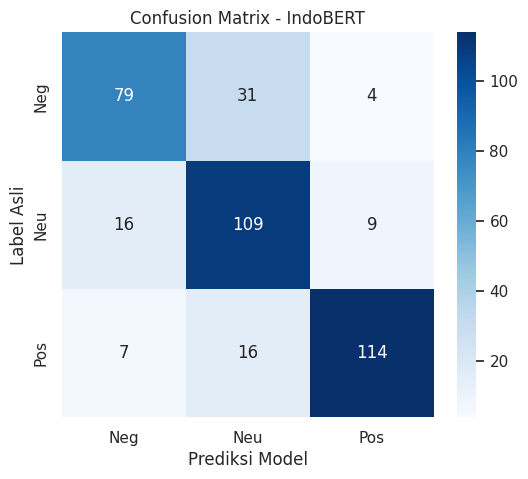


🔍 TOTAL KESALAHAN: 83 dari 385 data

🔴 KESALAHAN FATAL (Positif <-> Negatif): 11 Kasus
                                                                                                                                                                                                                              text label_str pred_str
          kemarin waktu kubaca isinya sebenernya tidak jauh beda sama kitab undang undang hukum acara pidana lama tapi kitab undang undang hukum acara pidana baru lebih detail arah salah malah jadi memperkuat institusi seragam  Negative Positive
                                                          harusnya restorative justice milik kitab undang undang hukum acara pidana baru tidak menjadikan pernikahan korban terutama rudapaksa cabul kekerasan seksual jalan damai  Negative Positive
                                                                                                                                                rek tarima wae iyeu rancangan 

Map:   0%|          | 0/385 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Sedang memprediksi data test...



📊 AKURASI FINAL: 0.7792

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative       0.66      0.86      0.75       114
     Neutral       0.76      0.67      0.71       134
    Positive       0.96      0.82      0.88       137

    accuracy                           0.78       385
   macro avg       0.79      0.78      0.78       385
weighted avg       0.80      0.78      0.78       385



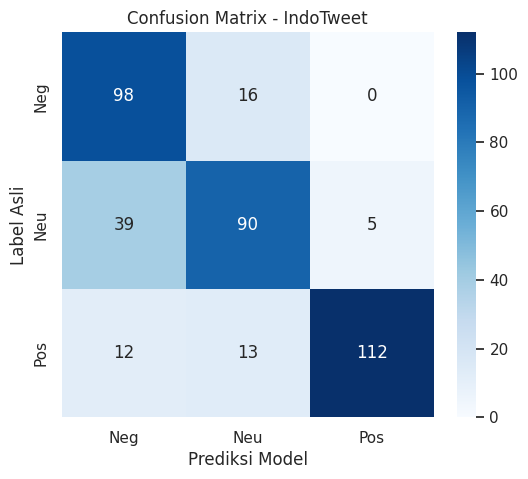


🔍 TOTAL KESALAHAN: 85 dari 385 data

🔴 KESALAHAN FATAL (Positif <-> Negatif): 12 Kasus
                                                                                                                                                                                                                                                                           text label_str pred_str
salah satu sumber persoalan bangsa hoax ketua dewan perwakilan rakyat republik indonesia puan maharani meminta masyarakat tidak termakan hoaks terkait kitab undang undang hukum acara pidana jangan sampe terprovokasi berita hoax sengaja disebarkan menciptakan kegaduhan cc  Positive Negative
                                  undercover buying gt menyamar jadi pembeli utamanya barang ilegal narkoba kriminal kotor menolak kitab undang undang hukum acara pidana pribadi accountability penyidik terkait kesalahan proses penyidikan termasuk bilamana unsur kekerasan  Positive Negative
                                       

In [25]:
# ==========================================
# CHUNK 3 (DL EDITION): ANALISIS KESALAHAN INDOBERT & INDOTWEET
# ==========================================
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from datasets import Dataset
import os

# 1. SETUP DATA (Harus SAMA PERSIS dengan Chunk 1 agar valid)
print("📂 Menyiapkan Data Test...")
# Auto-detect path
file_path = ""
possible_paths = ["data_kuhap_final_clean.csv", "/content/data_kuhap_final_clean.csv", "/kaggle/input/dataset-kelompok-12/data_kuhap_final_clean.csv"]
for path in possible_paths:
    if os.path.exists(path): file_path = path; break

if not file_path:
    # Cari manual
    for root in ['/content', '/kaggle/input']:
        for d, _, f in os.walk(root):
            if "data_kuhap_final_clean.csv" in f: file_path = os.path.join(d, "data_kuhap_final_clean.csv"); break
        if file_path: break

df = pd.read_csv(file_path)
df['clean_text_final'] = df['clean_text_final'].fillna("")

# Split 80:20 (Konsisten dengan training)
_, test_texts, _, test_labels = train_test_split(
    df['clean_text_final'].tolist(),
    df['Sentimen'].tolist(),
    test_size=0.2,
    stratify=df['Sentimen'],
    random_state=42
)

# Ambil teks asli untuk dibaca manusia (sebelum preprocessing jika ada, tapi di sini kita pakai clean text final)
# Kita simpan di dataframe kecil untuk analisis
df_test = pd.DataFrame({'text': test_texts, 'label': test_labels})
hf_test = Dataset.from_pandas(df_test)

# List Model yang akan dianalisis
target_models = ["IndoBERT", "IndoTweet"]
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# ---------------------------------------------------------
# FUNGSI ANALISIS
# ---------------------------------------------------------
def analyze_transformer(model_name):
    model_path = f"./final_model_{model_name}_tuned"
    
    if not os.path.exists(model_path):
        print(f"⚠️ Model {model_name} tidak ditemukan di {model_path}. Skip.")
        return

    print(f"\n" + "="*60)
    print(f"🕵️‍♂️ BEDAH KASUS: {model_name}")
    print("="*60)
    
    # A. Load Model & Tokenizer
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        model = AutoModelForSequenceClassification.from_pretrained(model_path)
    except Exception as e:
        print(f"Gagal load model: {e}")
        return

    # B. Tokenisasi Data Test
    def tokenize(e):
        return tokenizer(e['text'], padding="max_length", truncation=True, max_length=128)
    
    tokenized_test = hf_test.map(tokenize, batched=True)
    
    # C. Prediksi (Pakai Trainer agar support GPU otomatis)
    trainer = Trainer(model=model)
    print("Sedang memprediksi data test...")
    raw_pred, _, _ = trainer.predict(tokenized_test)
    y_pred = np.argmax(raw_pred, axis=1)
    
    # D. Metrics & Report
    acc = accuracy_score(test_labels, y_pred)
    print(f"\n📊 AKURASI FINAL: {acc:.4f}")
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(test_labels, y_pred, target_names=['Negative', 'Neutral', 'Positive']))
    
    # E. Visualisasi Confusion Matrix
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Neg', 'Neu', 'Pos'], 
                yticklabels=['Neg', 'Neu', 'Pos'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Label Asli')
    plt.xlabel('Prediksi Model')
    plt.show()
    
    # F. Analisis Kualitatif (Tampilkan Kesalahan)
    df_test['pred'] = y_pred
    df_test['label_str'] = df_test['label'].map(label_map)
    df_test['pred_str'] = df_test['pred'].map(label_map)
    
    # Filter Error
    errors = df_test[df_test['label'] != df_test['pred']]
    print(f"\n🔍 TOTAL KESALAHAN: {len(errors)} dari {len(df_test)} data")
    
    # 1. Kesalahan Fatal (Polaritas Terbalik)
    fatal = errors[
        ((errors['label_str']=='Positive') & (errors['pred_str']=='Negative')) | 
        ((errors['label_str']=='Negative') & (errors['pred_str']=='Positive'))
    ]
    
    print(f"\n🔴 KESALAHAN FATAL (Positif <-> Negatif): {len(fatal)} Kasus")
    if not fatal.empty:
        print(fatal[['text', 'label_str', 'pred_str']].head(5).to_string(index=False))
    else:
        print("Hebat! Tidak ada kesalahan fatal (model paham polaritas).")
        
    # 2. Kesalahan Ambiguitas (Netral vs Sentimen)
    ambigu = errors[
        (errors['label_str']=='Neutral') | (errors['pred_str']=='Neutral')
    ]
    print(f"\n🟠 KESALAHAN AMBIGUITAS (Netral <-> Sentimen): {len(ambigu)} Kasus")
    if not ambigu.empty:
        print(ambigu[['text', 'label_str', 'pred_str']].head(3).to_string(index=False))
        
    print("-" * 60)

# ---------------------------------------------------------
# EKSEKUSI
# ---------------------------------------------------------
for model in target_models:
    analyze_transformer(model)

## Analisis Kesalahan (Machine Learning)


📘 LAPORAN ANALISIS MENDALAM: SVM (Poly)

1️⃣  PERFORMA KESELURUHAN
------------------------------
              precision    recall  f1-score   support

    Negative       0.80      0.85      0.83       114
     Neutral       0.79      0.87      0.83       134
    Positive       0.98      0.85      0.91       137

    accuracy                           0.85       385
   macro avg       0.86      0.85      0.85       385
weighted avg       0.86      0.85      0.86       385


2️⃣  PETA KESALAHAN (CONFUSION MATRIX)


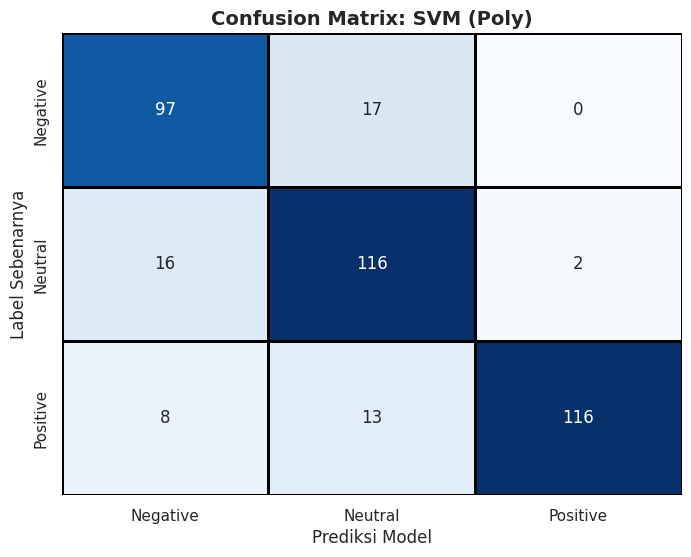


3️⃣  CONTOH TWEET YANG SALAH DITEBAK

🔸 ERROR FATAL: Positif dikira Negatif (Pesimis) (Total: 8)
   1. "rek tarima wae iyeu rancangan undang undang kitab undang undang hukum acara pidana"
      👉 Asli: Positive | Prediksi: Negative
   2. "banyak teriak darurat kitab undang undang hukum acara pidana padahal belum baca satu pasal"
      👉 Asli: Positive | Prediksi: Negative
   3. "sbnrnya apa mnjdi keistimewaan polisi kitab undang undang hukum acara pidana tugas selesai smpe penangkapn aja sdgkn dilimpahkn pengadilan jobnya jaks..."
      👉 Asli: Positive | Prediksi: Negative
   ----------------------------------------

🔸 ERROR FATAL: Negatif dikira Positif (Optimis) (Total: 0)
   (Tidak ada kesalahan tipe ini. Bagus!)

🔸 ERROR AMBIGU: Bingung membedakan Netral (Total: 48)
   1. "hemm menjawab mudahnya otoritas mengendalikan narasi undang undang komisi pemberantasan korupsi omnibuslaw putusan mahkamah konstitusi gelar pahlawan ..."
      👉 Asli: Negative | Prediksi: Neutral
   2. "benar

In [28]:
# ==========================================
# CHUNK 3: ANALISIS KESALAHAN (VISUALISASI RAPI)
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Helper function untuk print teks error dengan rapi
def print_error_samples(df_errors, title, limit=3):
    print(f"\n🔸 {title} (Total: {len(df_errors)})")
    if df_errors.empty:
        print("   (Tidak ada kesalahan tipe ini. Bagus!)")
        return

    for i, row in enumerate(df_errors.head(limit).itertuples(), 1):
        # Potong teks jika terlalu panjang biar tidak memenuhi layar
        text_preview = row.Teks_Asli if len(row.Teks_Asli) < 150 else row.Teks_Asli[:150] + "..."
        print(f"   {i}. \"{text_preview}\"")
        print(f"      👉 Asli: {row.Label_Benar} | Prediksi: {row.Prediksi_Model}")
    print("   " + "-"*40)

# Cek prasyarat
if 'final_best_model' not in locals():
    print("⚠️ Error: Jalankan Chunk 2 dulu untuk mendapatkan model terbaik.")
else:
    print(f"\n📘 LAPORAN ANALISIS MENDALAM: {final_best_entry['Model']}")
    print("="*70)

    # 1. PERSIAPAN DATA TEST
    X_err = features_db[final_best_feature_name]
    X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
        X_err, y_target, test_size=0.2, stratify=y_target, random_state=42
    )
    # Ambil teks asli
    _, X_text_test, _, _ = train_test_split(
        df['clean_text_final'], y_target, test_size=0.2, stratify=y_target, random_state=42
    )

    # 2. PREDIKSI
    y_pred_e = final_best_model.predict(X_test_e)
    target_names = ['Negative', 'Neutral', 'Positive']

    # 3. METRIK PERFORMA
    print("\n1️⃣  PERFORMA KESELURUHAN")
    print("-" * 30)
    print(classification_report(y_test_e, y_pred_e, target_names=target_names))

    # 4. VISUALISASI CONFUSION MATRIX
    print("\n2️⃣  PETA KESALAHAN (CONFUSION MATRIX)")
    cm = confusion_matrix(y_test_e, y_pred_e)
    # Hitung persentase
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                linewidths=1, linecolor='black', cbar=False)
    plt.title(f'Confusion Matrix: {final_best_entry["Model"]}', fontsize=14, fontweight='bold')
    plt.xlabel('Prediksi Model', fontsize=12)
    plt.ylabel('Label Sebenarnya', fontsize=12)
    plt.show()

    # 5. BEDAH KASUS ERROR
    print("\n3️⃣  CONTOH TWEET YANG SALAH DITEBAK")
    print("=" * 70)
    
    # Buat DataFrame Error yang rapi
    df_err = pd.DataFrame({
        'Teks_Asli': X_text_test.values,
        'Label_Benar': y_test_e,
        'Prediksi_Model': y_pred_e
    })
    label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    df_err['Label_Benar'] = df_err['Label_Benar'].map(label_map)
    df_err['Prediksi_Model'] = df_err['Prediksi_Model'].map(label_map)
    
    # Filter Error
    errors = df_err[df_err['Label_Benar'] != df_err['Prediksi_Model']]
    
    # Kategori: FATAL (Positif <-> Negatif)
    fatal_pos_neg = errors[(errors['Label_Benar']=='Positive') & (errors['Prediksi_Model']=='Negative')]
    fatal_neg_pos = errors[(errors['Label_Benar']=='Negative') & (errors['Prediksi_Model']=='Positive')]
    
    # Kategori: AMBIGU (Salah tebak ke/dari Netral)
    ambigu = errors[(errors['Label_Benar']=='Neutral') | (errors['Prediksi_Model']=='Neutral')]

    # Print menggunakan helper function
    print_error_samples(fatal_pos_neg, "ERROR FATAL: Positif dikira Negatif (Pesimis)")
    print_error_samples(fatal_neg_pos, "ERROR FATAL: Negatif dikira Positif (Optimis)")
    print_error_samples(ambigu, "ERROR AMBIGU: Bingung membedakan Netral")

    # 6. FEATURE IMPORTANCE (Jika Ada)
    model_step = final_best_model.named_steps['clf'] if hasattr(final_best_model, 'named_steps') else final_best_model
    
    if hasattr(model_step, 'feature_importances_') or hasattr(model_step, 'coef_'):
        print("\n4️⃣  KATA KUNCI PENENTU (Top 10)")
        print("-" * 30)
        
        try:
            # Re-create vocab mapping
            from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
            if 'TF-IDF' in final_best_feature_name: vec = TfidfVectorizer(max_features=5000)
            else: vec = CountVectorizer(max_features=5000)
            vec.fit(df['clean_text_final'].fillna(""))
            feature_names = np.array(vec.get_feature_names_out())

            # Extract Importance
            if hasattr(model_step, 'feature_importances_'):
                importances = model_step.feature_importances_
            elif hasattr(model_step, 'coef_'):
                importances = np.mean(np.abs(model_step.coef_), axis=0)
            
            # Sort & Display
            indices = np.argsort(importances)[::-1][:10]
            top_features = pd.DataFrame({
                'Kata Kunci': feature_names[indices],
                'Bobot Pengaruh': importances[indices]
            })
            print(top_features.to_string(index=False))
            
        except Exception as e:
            print(f"(Gagal mengekstrak kata kunci: {e})")
    else:
        print("\n4️⃣  KATA KUNCI PENENTU")
        print("   (Model ini tidak mendukung ekstraksi fitur kata per kata secara langsung)")
    
    print("\n" + "="*70)

## Aspect Based Sentiment Analysis & Topic Modeling

In [32]:
# ==========================================
# CHUNK 4: ABSA & TOPIC MODELING 
# ==========================================

import pandas as pd
import os
import shutil
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# ---------------------------------------------------------
# 1. SETUP & FUNGSI BANTUAN
# ---------------------------------------------------------
def print_separator(title, char="=", length=80):
    print(f"\n{char*length}\n{title}\n{char*length}")

def get_file_path():
    # Auto-detect path
    for root in ['/content', '/kaggle/input']:
        for d, _, f in os.walk(root):
            if "data_kuhap_final_clean.csv" in f:
                return os.path.join(d, "data_kuhap_final_clean.csv")
            # Fallback csv lain
            for file in f:
                if file.endswith(".csv") and "clean" in file:
                    return os.path.join(d, file)
    return None

# Load Data
print_separator("📂 MEMUAT DATASET")
file_path = get_file_path()
if not file_path: raise FileNotFoundError("❌ File CSV tidak ditemukan!")

print(f"✅ Menggunakan file: {file_path}")
df = pd.read_csv(file_path)
df['clean_text_final'] = df['clean_text_final'].fillna("")

# Cek Kolom Waktu
use_temporal = False
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
    df = df.dropna(subset=['created_at'])
    use_temporal = True
    print("✅ Analisis Temporal (Topics over Time) AKTIF.")

# Definisi Sentimen
sentiments = {
    0: "NEGATIVE",  # Komplain / Kritik
    1: "NEUTRAL",   # Berita / Informasi
    2: "POSITIVE"   # Dukungan / Harapan
}

# ---------------------------------------------------------
# 2. ENGINE ANALISIS UTAMA
# ---------------------------------------------------------
for sent_code, sent_name in sentiments.items():
    print_separator(f"🚀 ANALISIS MENDALAM: SENTIMEN {sent_name}")
    
    # A. Filter Data
    df_subset = df[df['Sentimen'] == sent_code].copy()
    docs = df_subset['clean_text_final'].tolist()
    timestamps = df_subset['created_at'].tolist() if use_temporal else None
    
    count_docs = len(docs)
    print(f"📊 Jumlah Dokumen: {count_docs}")
    
    if count_docs < 10:
        print(f"⚠️ Data terlalu sedikit (<10) untuk analisis topik mendalam. Skip.")
        continue

    # B. Buat Folder Output
    output_dir = f"absa_results/{sent_name}"
    os.makedirs(output_dir, exist_ok=True)

    # C. Konfigurasi BERTopic (Detail Tinggi)
    # ngram_range=(1, 3): Menangkap frasa panjang (contoh: "pelanggaran hak asasi")
    # min_df=2: Hapus kata yang cuma muncul di 1 tweet (typo/unik)
    vectorizer_model = CountVectorizer(ngram_range=(1, 3), min_df=2)
    
    # min_topic_size dinamis agar tidak crash
    min_size = 5 if count_docs > 100 else 2
    
    topic_model = BERTopic(
        language="multilingual",
        vectorizer_model=vectorizer_model,
        verbose=True,
        min_topic_size=min_size,
        nr_topics="auto", # Reduksi otomatis topik kembar
        calculate_probabilities=False 
    )
    
    # D. Training
    try:
        topics, probs = topic_model.fit_transform(docs)
    except Exception as e:
        print(f"❌ Gagal training topik: {e}")
        continue

    # E. Laporan Detail Topik
    freq = topic_model.get_topic_info()
    
    # Bersihkan nama topik
    freq['Clean_Name'] = freq['Name'].apply(lambda x: "_".join(x.split("_")[1:]))
    
    print("\n📌 DAFTAR TOPIK TERBENTUK:")
    print(f"{'ID':<4} | {'Count':<5} | {'Nama Topik (Representasi)'}")
    print("-" * 60)
    for index, row in freq.head(10).iterrows():
        label = "[Outlier]" if row['Topic'] == -1 else row['Clean_Name']
        print(f"{row['Topic']:<4} | {row['Count']:<5} | {label}")

    # F. BEDAH MENDALAM (Deep Dive per Topik)
    print_separator(f"🔍 BEDAH DETAIL ASPEK ({sent_name})")
    
    # Ambil Top 5 Topik Nyata (Bukan Outlier -1)
    real_topics = freq[freq['Topic'] != -1]['Topic'].head(5).tolist()
    
    for t_id in real_topics:
        t_info = freq[freq['Topic'] == t_id].iloc[0]
        print(f"\n🔹 TOPIK {t_id}: {t_info['Clean_Name'].upper()} (Jumlah: {t_info['Count']} Tweet)")
        
        # 1. Kata Kunci & Bobotnya (c-TF-IDF score)
        print("   🔑 Kata Kunci Utama (Bobot):")
        keywords = topic_model.get_topic(t_id)
        # Format: kata (0.5), kata2 (0.4)
        kw_str = ", ".join([f"{k[0]} ({k[1]:.2f})" for k in keywords[:8]])
        print(f"      {kw_str}")
        
        # 2. Dokumen Representatif (Tweet yang paling mewakili topik ini)
        print("   📄 Contoh Tweet Representatif:")
        # Kita cari tweet asli di df_subset yang punya topik ini
        # (Menggunakan representative_docs dari BERTopic kadang terpotong, jadi kita cari manual yang terbaik)
        df_subset['Temp_Topic'] = topics
        samples = df_subset[df_subset['Temp_Topic'] == t_id]['full_text'].head(3).tolist()
        
        for i, txt in enumerate(samples, 1):
            clean_txt = txt.replace('\n', ' ')
            preview = clean_txt if len(clean_txt) < 150 else clean_txt[:150] + "..."
            print(f"      {i}. \"{preview}\"")
        
    # G. Export Visualisasi HTML
    print(f"\n💾 Menyimpan Visualisasi ke '{output_dir}/'...")
    
    # 1. Barchart Kata Kunci
    topic_model.visualize_barchart(top_n_topics=10).write_html(f"{output_dir}/keywords.html")
    
    # 2. Hierarki (Hubungan antar topik)
    topic_model.visualize_hierarchy(top_n_topics=20).write_html(f"{output_dir}/hierarchy.html")
    
    # 3. Heatmap (Kesamaan topik)
    topic_model.visualize_heatmap(top_n_topics=20).write_html(f"{output_dir}/heatmap.html")
    
    # 4. Topics over Time (Jika ada waktu)
    if use_temporal:
        try:
            topics_over_time = topic_model.topics_over_time(docs, timestamps, nr_bins=10)
            topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=5).write_html(f"{output_dir}/timeline.html")
            print("   ✅ Grafik Timeline berhasil dibuat.")
        except Exception as e:
            print(f"   ⚠️ Gagal membuat Timeline: {e}")

    # H. Simpan Data Hasil Klasifikasi
    # Mapping ID Topik ke Nama Topik
    topic_map = {row['Topic']: row['Clean_Name'] for _, row in freq.iterrows()}
    df_subset['Topic_ID'] = topics
    df_subset['Topic_Name'] = df_subset['Topic_ID'].map(lambda x: topic_map.get(x, "Outlier"))
    
    save_csv = f"{output_dir}/hasil_topik_{sent_name.lower()}.csv"
    df_subset[['created_at', 'full_text', 'Topic_ID', 'Topic_Name']].to_csv(save_csv, index=False)
    print(f"✅ Data CSV tersimpan di: {save_csv}")

print_separator("🎉 SELESAI! SEMUA ANALISIS ABSA TUNTAS")
print("Tips: Download folder 'absa_results' untuk melihat file HTML visualisasi.")

2025-12-04 13:10:24,037 - BERTopic - Embedding - Transforming documents to embeddings.



📂 MEMUAT DATASET
✅ Menggunakan file: /kaggle/input/dataset-kelompok-12/data_kuhap_final_clean.csv
✅ Analisis Temporal (Topics over Time) AKTIF.

🚀 ANALISIS MENDALAM: SENTIMEN NEGATIVE
📊 Jumlah Dokumen: 571


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

2025-12-04 13:10:27,659 - BERTopic - Embedding - Completed ✓
2025-12-04 13:10:27,660 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-04 13:10:28,513 - BERTopic - Dimensionality - Completed ✓
2025-12-04 13:10:28,515 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-04 13:10:28,535 - BERTopic - Cluster - Completed ✓
2025-12-04 13:10:28,536 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-04 13:10:28,594 - BERTopic - Representation - Completed ✓
2025-12-04 13:10:28,594 - BERTopic - Topic reduction - Reducing number of topics
2025-12-04 13:10:28,603 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-04 13:10:28,645 - BERTopic - Representation - Completed ✓
2025-12-04 13:10:28,647 - BERTopic - Topic reduction - Reduced number of topics from 25 to 5



📌 DAFTAR TOPIK TERBENTUK:
ID   | Count | Nama Topik (Representasi)
------------------------------------------------------------
-1   | 229   | [Outlier]
0    | 281   | undang_undang undang_hukum_hukum acara
1    | 41    | indonesia_undang_republik indonesia_republik
2    | 13    | undang_undang undang_the_we
3    | 7     | undang_ketok_pak_hari

🔍 BEDAH DETAIL ASPEK (NEGATIVE)

🔹 TOPIK 0: UNDANG_UNDANG UNDANG_HUKUM_HUKUM ACARA (Jumlah: 281 Tweet)
   🔑 Kata Kunci Utama (Bobot):
      undang (0.11), undang undang (0.08), hukum (0.07), hukum acara (0.07), acara (0.07), hukum acara pidana (0.07), acara pidana (0.07), pidana (0.07)
   📄 Contoh Tweet Representatif:
      1. "@tempodotco Serius ini pada mau DIAM SAJA? RUU Perampasan aja gak terealisasi tiba2 RUU KUHAP baru masuk langsung SAH. PARAH SIH ini... Memang kebodoh..."
      2. "bilang rakyat jangan termakan hoaks tp dengan mengesahkan KUHAP ini bukti klau emang nih uu engga beres apa yg dikejar kok buru2 bgt buat mengesahkan ..."
 

...

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

2025-12-04 13:10:39,450 - BERTopic - Embedding - Completed ✓
2025-12-04 13:10:39,450 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-04 13:10:40,502 - BERTopic - Dimensionality - Completed ✓
2025-12-04 13:10:40,503 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-04 13:10:40,528 - BERTopic - Cluster - Completed ✓
2025-12-04 13:10:40,529 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-04 13:10:40,587 - BERTopic - Representation - Completed ✓
2025-12-04 13:10:40,588 - BERTopic - Topic reduction - Reducing number of topics
2025-12-04 13:10:40,596 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-04 13:10:40,652 - BERTopic - Representation - Completed ✓
2025-12-04 13:10:40,654 - BERTopic - Topic reduction - Reduced number of topics from 18 to 16



📌 DAFTAR TOPIK TERBENTUK:
ID   | Count | Nama Topik (Representasi)
------------------------------------------------------------
-1   | 113   | [Outlier]
0    | 151   | hukum_undang_pidana_hukum acara pidana
1    | 109   | undang_undang undang_hoax_undang hukum acara
2    | 96    | undang_penyadapan_undang undang_hoax
3    | 46    | penangkapan_ketat_undang_undang undang
4    | 36    | undang_undang undang_panik_hoax
5    | 33    | undang_undang undang_hoax_hukum
6    | 20    | indonesia_lebih_hukum_acara pidana baru
7    | 18    | pamflet_hoax_isinya_lawan disinformasi hoax
8    | 17    | undang_hoax_undang undang_undang hukum acara

🔍 BEDAH DETAIL ASPEK (POSITIVE)

🔹 TOPIK 0: HUKUM_UNDANG_PIDANA_HUKUM ACARA PIDANA (Jumlah: 151 Tweet)
   🔑 Kata Kunci Utama (Bobot):
      hukum (0.05), undang (0.05), pidana (0.04), hukum acara pidana (0.04), hukum acara (0.04), acara pidana (0.04), acara (0.04), undang undang (0.04)
   📄 Contoh Tweet Representatif:
      1. "Pasal-pasal itu bakal membu

10it [00:00, 79.27it/s]

   ✅ Grafik Timeline berhasil dibuat.
✅ Data CSV tersimpan di: absa_results/POSITIVE/hasil_topik_positive.csv

🎉 SELESAI! SEMUA ANALISIS ABSA TUNTAS
Tips: Download folder 'absa_results' untuk melihat file HTML visualisasi.
